# UIUC Housing – Apartment Scoring v3
- Pet fee 가산점 방식
- ICON 등 per-unit 가격 → beds로 나눠서 per-person 통일
- **beds+baths 조합별 비교** (4x2 vs 4x4 분리, 공정한 비교)
- 가성비 보정 value_bonus

## 0. Setup

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import warnings
warnings.filterwarnings('ignore')

df_amenities = pd.read_csv('uiuc-housing-amenities-final.csv')
df_utilities = pd.read_csv('uiuc-housing-utilities-final.csv')
df_pricing   = pd.read_csv('uiuc-housing-pricing.csv')

print('amenities:', df_amenities.shape)
print('utilities:', df_utilities.shape)
print('pricing:  ', df_pricing.shape)

amenities: (12, 10)
utilities: (12, 9)
pricing:   (137, 7)


---
## 1. Amenity Score
pet_allowed은 여기서 제외 → pet_fee 섹션에서 따로 처리

In [11]:
df_a = df_amenities.copy().set_index('apt_name')
df_a = df_a.replace({'Yes': 1, 'No': 0}).fillna(0.5)

amenity_weights = {
    'gym':                   0.08,
    'pool':                  0.07,
    'study_lounge':          0.15,
    'parking':               0.08,
    'rooftop / courtyard':   0.07,
    'in_unit_washer/dryer':  0.20,
    'Elevator':              0.05,
    'Bicycle Storage':       0.10, 
}
total_w = sum(amenity_weights.values())
amenity_weights = {k: v/total_w for k, v in amenity_weights.items()}
valid_cols = [c for c in amenity_weights if c in df_a.columns]
df_a['amenity_score'] = sum(df_a[col]*amenity_weights[col] for col in valid_cols)

print('=== Amenity Score ===')
print(df_a['amenity_score'].sort_values(ascending=False).round(3))

=== Amenity Score ===
apt_name
Here            0.900
Hub             0.900
Dean            0.900
Yugo            0.900
707             0.900
Octave          0.900
Latitude        0.900
ICON            0.812
75 Armory       0.525
T3              0.475
Gregory         0.438
Illini Manor    0.275
Name: amenity_score, dtype: float64


---
## 2. Pet Fee 가산점

- **pet 불가 아파트**: 0점
- **pet 가능 아파트**: monthly 환산 비용 역정규화 → 낮을수록 높은 점수

In [12]:
# monthly 환산: one_time/12 + monthly
pet_monthly_fee = {
    'Hub':      250/12 + 25,   # ~45.8/mo
    'ICON':     250/12,        # ~20.8/mo  <- 가장 저렴
    'Yugo':     200/12 + 30,   # ~46.7/mo
    'Octave':   250/12 + 25,   # ~45.8/mo
    '707':      350/12 + 35,   # ~64.2/mo
    'Latitude': 400/12 + 50,   # ~83.3/mo  <- 가장 비쌈
}

pet_vals = np.array(list(pet_monthly_fee.values()))
pet_min, pet_max = pet_vals.min(), pet_vals.max()

all_apts = df_amenities['apt_name'].tolist()
pet_score_dict = {}
for apt in all_apts:
    if apt in pet_monthly_fee:
        val = pet_monthly_fee[apt]
        pet_score_dict[apt] = round(1 - (val - pet_min) / (pet_max - pet_min), 3)
    else:
        pet_score_dict[apt] = 0.0

pet_score_series = pd.Series(pet_score_dict, name='pet_score')
print('=== Pet Fee Score ===')
print(pet_score_series.sort_values(ascending=False).round(3))

=== Pet Fee Score ===
ICON            1.000
Hub             0.600
Octave          0.600
Yugo            0.587
707             0.307
Here            0.000
Dean            0.000
Gregory         0.000
T3              0.000
75 Armory       0.000
Illini Manor    0.000
Latitude        0.000
Name: pet_score, dtype: float64


---
## 3. Price Score — beds+baths 조합별 비교

4x2와 4x4를 **따로** 비교해서 화장실 수에 따른 불공평한 페널티 방지.

| 조합 | 비교 아파트 |
|------|------------|
| 4x2  | Yugo, 75 Armory, 707, Dean, Here, Hub |
| 4x4  | ICON, Latitude, Octave, 707, Dean, Here, Hub |

In [13]:
def parse_rent(val):
    if pd.isna(val): return np.nan
    val = str(val).replace(',', '').strip()
    if '-' in val:
        parts = val.split('-')
        try: return (float(parts[0].strip()) + float(parts[1].strip())) / 2
        except: return np.nan
    try: return float(val)
    except: return np.nan

df_p = df_pricing.copy()
df_p['rent_num'] = df_p['rent ($)'].apply(parse_rent)

def to_per_person(row):
    if row['per_person'] == 'Yes': return row['rent_num']
    beds = max(row['beds'], 1)
    return row['rent_num'] / beds if not pd.isna(row['rent_num']) else np.nan

df_p['rent_pp'] = df_p.apply(to_per_person, axis=1)

# beds+baths 조합 컬럼 생성
df_p['combo'] = df_p.apply(
    lambda r: 'Studio' if r['beds'] == 0 else f"{int(r['beds'])}x{int(r['baths'])}",
    axis=1
)

# 아파트 × 조합 중앙값
combo_median = df_p.groupby(['apt_name', 'combo'])['rent_pp'].median().reset_index()

print('=== 조합별 per-person 가격 ===')
print(combo_median.sort_values(['combo', 'rent_pp']).to_string(index=False))

=== 조합별 per-person 가격 ===
    apt_name  combo     rent_pp
Illini Manor    1x1  980.000000
     Gregory    1x1 1550.000000
          T3    1x1 1594.000000
        ICON    1x1 1652.000000
    Latitude    1x1 1659.000000
        Yugo    1x1 1669.000000
      Octave    1x1 1849.000000
         707    1x1 2049.000000
        Dean    1x1 2190.000000
         Hub    1x1 2275.000000
          T3    2x1 1001.500000
        Dean    2x1 1430.000000
         Hub    2x1 1609.000000
   75 Armory    2x2 1040.000000
    Latitude    2x2 1049.000000
        ICON    2x2 1076.000000
        Yugo    2x2 1089.000000
      Octave    2x2 1349.000000
         707    2x2 1374.000000
         Hub    2x2 1630.000000
        Here    2x2 1669.000000
        Dean    2x2 1830.000000
          T3    3x1  969.000000
   75 Armory    3x2  935.000000
         Hub    3x2 1445.000000
        ICON    3x3 1008.666667
   75 Armory    3x3 1027.500000
      Octave    3x3 1209.000000
         707    3x3 1339.000000
     Gregory  

In [14]:
# 조합 내부 역정규화 (낮을수록 높은 점수)
combo_median['price_score'] = np.nan
for combo, group in combo_median.groupby('combo'):
    vals = group['rent_pp'].dropna()
    if len(vals) < 2:
        # 해당 조합에 아파트가 1개뿐 → 중간값 0.5
        combo_median.loc[group.index, 'price_score'] = 0.5
        continue
    mn, mx = vals.min(), vals.max()
    combo_median.loc[group.index, 'price_score'] = (
        1 - (group['rent_pp'] - mn) / (mx - mn)
    )

# 아파트별 평균 price score
price_score_series = combo_median.groupby('apt_name')['price_score'].mean()
price_score_series.name = 'price_score'

print('=== Price Score (조합별 비교 후 평균) ===')
print(price_score_series.sort_values(ascending=False).round(3))

=== Price Score (조합별 비교 후 평균) ===
apt_name
Illini Manor    1.000
75 Armory       0.893
Latitude        0.780
Gregory         0.780
ICON            0.778
T3              0.675
Yugo            0.595
Octave          0.486
Here            0.265
707             0.265
Dean            0.165
Hub             0.032
Name: price_score, dtype: float64


---
## 4. 최종 점수 통합

**가성비 보정 (value_bonus)**:
- `value_bonus = price_score × (1 - amenity_score) × 0.3` (max 0.2)
- amenity 낮지만 가격 저렴한 경우 (Gregory, 75 Armory 등) 불이익 완화

In [15]:
df_final = pd.DataFrame({
    'amenity_score': df_a['amenity_score'],
    'pet_score':     pet_score_series,
    'price_score':   price_score_series,
})

df_final['value_bonus'] = (
    df_final['price_score'] * (1 - df_final['amenity_score']) * 0.3
).clip(0, 0.2)

W_AMENITY = 0.40
W_PET     = 0.10
W_PRICE   = 0.40
W_VALUE   = 0.10

df_final['total_score'] = (
    df_final['amenity_score'] * W_AMENITY +
    df_final['pet_score']     * W_PET     +
    df_final['price_score']   * W_PRICE   +
    df_final['value_bonus']   * W_VALUE
).round(3)

df_final = df_final.sort_values('total_score', ascending=False)
print('=== 최종 점수 (0~1) ===')
print(df_final.round(3).to_string())

df_final.to_csv('housing_scores_v3.csv')
print('\n저장: housing_scores_v3.csv')

=== 최종 점수 (0~1) ===
              amenity_score  pet_score  price_score  value_bonus  total_score
ICON                  0.812      1.000        0.778        0.044        0.741
Latitude              0.900      0.000        0.780        0.023        0.674
Yugo                  0.900      0.587        0.595        0.018        0.658
Octave                0.900      0.600        0.486        0.015        0.616
75 Armory             0.525      0.000        0.893        0.127        0.580
Illini Manor          0.275      0.000        1.000        0.200        0.530
Gregory               0.438      0.000        0.780        0.132        0.500
707                   0.900      0.307        0.265        0.008        0.498
T3                    0.475      0.000        0.675        0.106        0.471
Here                  0.900      0.000        0.265        0.008        0.467
Hub                   0.900      0.600        0.032        0.001        0.433
Dean                  0.900      0.000      

---
## 5. 시각화 – 총점 & 카테고리 기여도

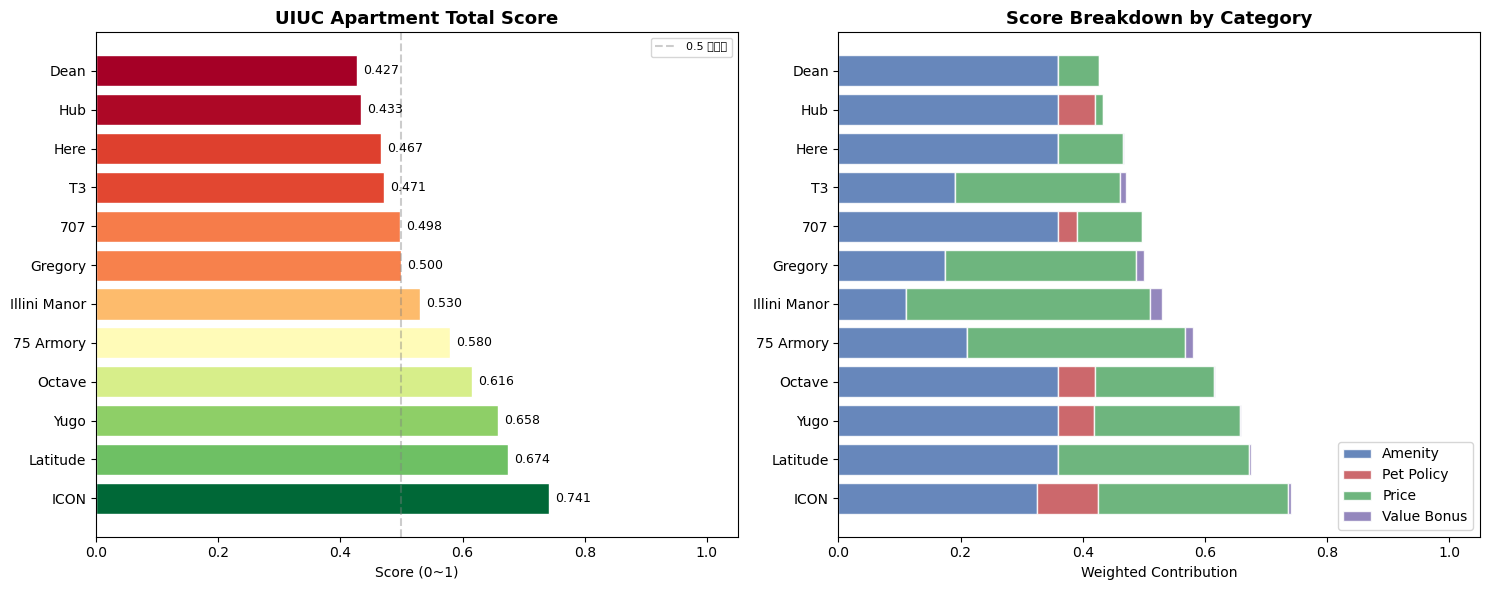

저장: housing_scores_v3.png


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

scores = df_final['total_score'].values.astype(float)
norm_scores = (scores - scores.min()) / (scores.max() - scores.min() + 1e-9)
colors = cm.RdYlGn(norm_scores)
axes[0].barh(df_final.index, scores, color=colors, edgecolor='white')
axes[0].set_xlim(0, 1.05)
axes[0].set_xlabel('Score (0~1)')
axes[0].set_title('UIUC Apartment Total Score', fontsize=13, fontweight='bold')
for i, (idx, row) in enumerate(df_final.iterrows()):
    axes[0].text(float(row['total_score']) + 0.01, i,
                 f"{float(row['total_score']):.3f}", va='center', fontsize=9)
axes[0].axvline(0.5, color='gray', linestyle='--', alpha=0.4, label='0.5 기준선')
axes[0].legend(fontsize=8)

contributions = pd.DataFrame({
    'Amenity':     df_final['amenity_score'].astype(float) * W_AMENITY,
    'Pet Policy':  df_final['pet_score'].astype(float)     * W_PET,
    'Price':       df_final['price_score'].astype(float)   * W_PRICE,
    'Value Bonus': df_final['value_bonus'].astype(float)   * W_VALUE,
}).fillna(0.0)
colors_stack = ['#4C72B0', '#C44E52', '#55A868', '#8172B2']
bottom = np.zeros(len(df_final), dtype=float)
for col, color in zip(contributions.columns, colors_stack):
    vals = contributions[col].values.astype(float)
    axes[1].barh(df_final.index, vals, left=bottom,
                 label=col, color=color, alpha=0.85, edgecolor='white')
    bottom += vals
axes[1].set_xlim(0, 1.05)
axes[1].set_xlabel('Weighted Contribution')
axes[1].set_title('Score Breakdown by Category', fontsize=13, fontweight='bold')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.savefig('housing_scores_v3.png', dpi=140, bbox_inches='tight')
plt.show()
print('저장: housing_scores_v3.png')

---
## 6. 시각화 – Beds+Baths 조합별 가격 비교

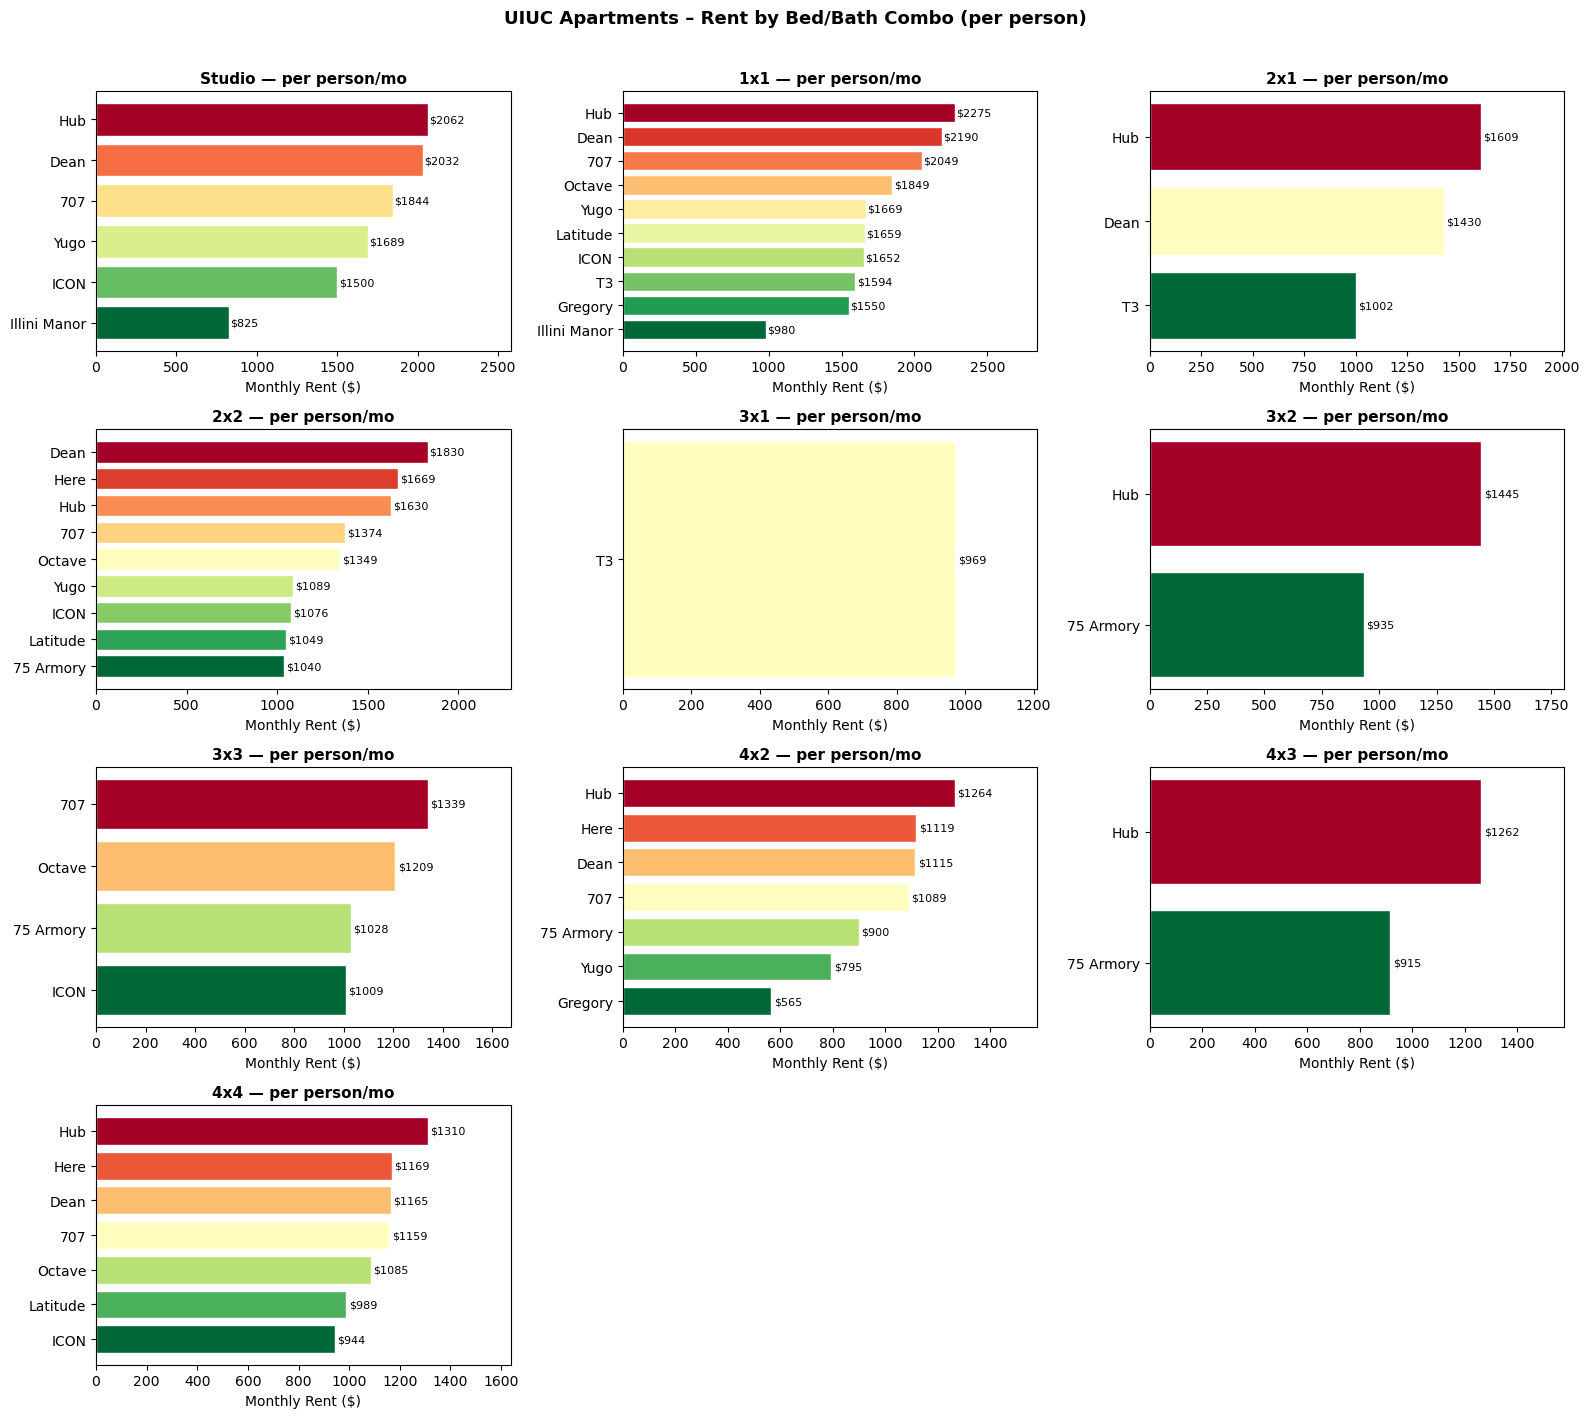

저장: rent_by_combo.png


In [17]:
combos_ordered = ['Studio','1x1','2x1','2x2','3x1','3x2','3x3','4x2','4x3','4x4']
existing_combos = [c for c in combos_ordered if c in combo_median['combo'].values]

ncols = 3
nrows = -(-len(existing_combos) // ncols)  # ceiling division
fig2, axes2 = plt.subplots(nrows, ncols, figsize=(16, nrows * 3.5))
axes2 = axes2.flatten()

for i, combo in enumerate(existing_combos):
    ax = axes2[i]
    sub = (combo_median[combo_median['combo'] == combo]
           .dropna(subset=['rent_pp'])
           .sort_values('rent_pp'))
    n = len(sub)
    bar_colors = [cm.RdYlGn_r(j / (n - 1) if n > 1 else 0.5) for j in range(n)]
    ax.barh(sub['apt_name'].values, sub['rent_pp'].values,
            color=bar_colors, edgecolor='white')
    ax.set_title(f'{combo} — per person/mo', fontsize=11, fontweight='bold')
    ax.set_xlabel('Monthly Rent ($)')
    for j, (_, r) in enumerate(sub.iterrows()):
        ax.text(r['rent_pp'] + 10, j, f'${r["rent_pp"]:.0f}', va='center', fontsize=8)
    ax.set_xlim(0, sub['rent_pp'].max() * 1.25)

for j in range(len(existing_combos), len(axes2)):
    axes2[j].set_visible(False)

plt.suptitle('UIUC Apartments – Rent by Bed/Bath Combo (per person)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('rent_by_combo.png', dpi=140, bbox_inches='tight')
plt.show()
print('저장: rent_by_combo.png')

---
## 7. Amenity-Price 상관관계 분석

Amenity score vs 4x4 rent 상관계수: 0.619
(양수 = 어메니티 좋을수록 비쌈)


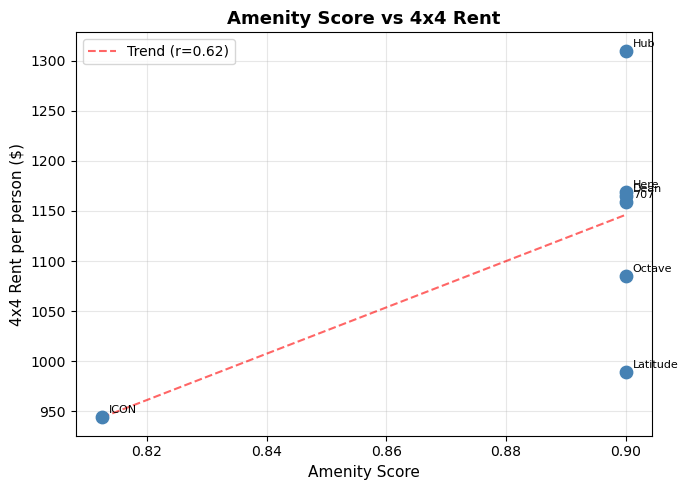

저장: amenity_price_corr.png


In [18]:
# 4x4 기준 per-person 가격 vs amenity score
rent_4x4 = combo_median[combo_median['combo'] == '4x4'].set_index('apt_name')['rent_pp']
corr_df = pd.DataFrame({
    'amenity_score': df_a['amenity_score'],
    'rent_4x4': rent_4x4,
}).dropna()

corr_val = corr_df.corr().loc['amenity_score', 'rent_4x4']
print(f'Amenity score vs 4x4 rent 상관계수: {corr_val:.3f}')
print('(양수 = 어메니티 좋을수록 비쌈)')

fig3, ax3 = plt.subplots(figsize=(7, 5))
ax3.scatter(corr_df['amenity_score'], corr_df['rent_4x4'],
            s=80, color='steelblue', zorder=3)
for apt, row in corr_df.iterrows():
    ax3.annotate(apt, (row['amenity_score'], row['rent_4x4']),
                 textcoords='offset points', xytext=(5, 3), fontsize=8)
z = np.polyfit(corr_df['amenity_score'], corr_df['rent_4x4'], 1)
p = np.poly1d(z)
xs = np.linspace(corr_df['amenity_score'].min(), corr_df['amenity_score'].max(), 100)
ax3.plot(xs, p(xs), 'r--', alpha=0.6, label=f'Trend (r={corr_val:.2f})')
ax3.set_xlabel('Amenity Score', fontsize=11)
ax3.set_ylabel('4x4 Rent per person ($)', fontsize=11)
ax3.set_title('Amenity Score vs 4x4 Rent', fontsize=13, fontweight='bold')
ax3.legend()
ax3.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('amenity_price_corr.png', dpi=130, bbox_inches='tight')
plt.show()
print('저장: amenity_price_corr.png')